In [3]:
import h5py
import pandas as pd
import numpy as np
import sys
from types import SimpleNamespace
import matplotlib.pyplot as plt
from astropy import units as u
from flossy.flossy import flossyGUI
from PyQt5.QtWidgets import QApplication

tic = 177162802

In [ ]:
file_name = "/Users/michi/Documents/Git/SPB-astroseismology/results_spb1.hdf5"
itprw = h5py.File(file_name)
list(itprw.keys())

df = pd.DataFrame()


In [ ]:
pw_file = f'C:/Users/michi/Documents/Git/SPB-astroseismology/pw_tic{tic}.csv'
# Periodogram CSV file
pg_file = f'C:/Users/michi/Documents/Git/SPB-astroseismology/pg_tic{tic}.csv'
# Read the CSV files
pw = pd.read_csv(pw_file) 
pg = pd.read_csv(pg_file)
# Extract relevant columns from the CSV files
pw_periods = 1/pw.frequency.values
pw_e_periods = pw.e_frequency.values * pw_periods**2
pw_amplitudes = pw.amp.values
pg_periods = 1/pg.freq.values
pg_amplitudes = pg.amp.values
# Give astropy units to the just extracted columns 
pw_periods *= u.day
pw_e_periods *= u.day
pw_amplitudes = pw_amplitudes * 1e-3 * u.dimensionless_unscaled # ppt
pg_periods *= u.day
pg_amplitudes = pg_amplitudes * 1e-3 * u.dimensionless_unscaled # ppt
# Give a title to the figure
title = f'TIC {tic}'
data = SimpleNamespace(
    pw_periods=pw_periods,
    pw_e_periods=pw_e_periods,
    pw_amplitudes=pw_amplitudes,
    pg_periods=pg_periods,
    pg_amplitudes=pg_amplitudes,
    title=title
)

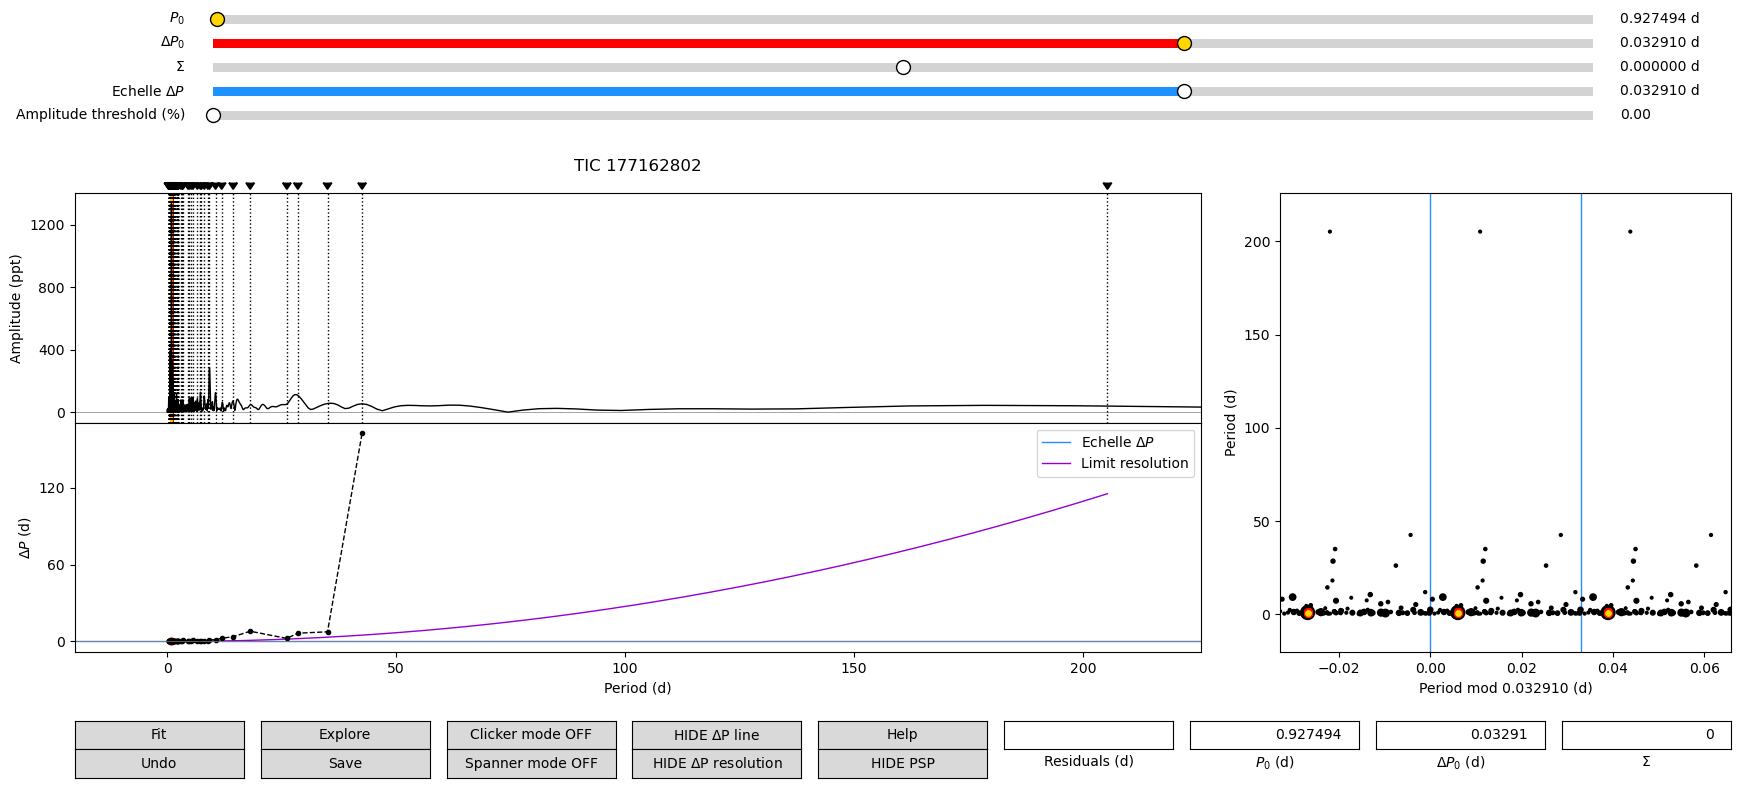

In [ ]:
GUI = flossyGUI(
        pw_periods=data.pw_periods,
        pw_e_periods=data.pw_e_periods,
        pw_amplitudes=data.pw_amplitudes,
        pg_periods=data.pg_periods,
        pg_amplitudes=data.pg_amplitudes,
        ID=data.title,
        freq_resolution=1/u.yr
    )
# Run the interface using a context manager
with GUI as flossy:
    app = QApplication([])
    plt.show()
    sys.exit(app.exec_())

In [5]:
import math
from pathlib import Path 

def two_space_prefixed(v: float):
    """Maak string met 10 decimalen en max. 2 leidende spaties,
    waarbij die spaties worden ingenomen door minteken/tiental/honderdtal."""
    s = f"{v:.10f}"
    prefix = 2
    if v < 0:
        prefix -= 1  # '-' neemt 1 plek
    # aantal cijfers in het integer-deel
    int_digits = len(str(int(abs(v)))) if abs(v) >= 1 else 1
    if int_digits >= 2:
        prefix -= 1
    if int_digits >= 3:
        prefix -= 2
    if prefix < 0:
        prefix = 0
    return (" " * prefix) + s

def write_amigo(df, path):
    """
    Schrijft een .amigo bestand met:
      - tab-delimiters
      - elke kolom gestart met twee spaties (opgevuld door cijfers/minteken)
      - header: '# per' gevolgd door '\t  e_per\t  ampl\t ...'
      - afsluitende '#'-lijn over de volledige breedte van de langste datarij
    """
    path = Path(path)

    cols_wanted = ["per", "e_per", "ampl", "e_ampl", "phase", "e_phase", "stopcrit"]

    if "stopcrit" not in df.columns:
        df["stopcrit"] = 4.0

    missing = [c for c in cols_wanted if c not in df.columns]
    if missing:
        raise ValueError(f"Ontbrekende kolommen: {missing}")

    # Header opbouwen: eerste veld '# per', overige '  naam', gescheiden door tabs
    headers = ["per", "e_per", "ampl", "e_ampl", "phase", "e_phase", "stopcrit"]
    header_line = "# "

    header_line = "# " + "\t  ".join(header + " " * (13 - len(header)) for header in headers)

    max_len = len(header_line)  # voor afsluitende ***-lijn

    with path.open("w", encoding="utf-8", newline="\n") as f:
        # header
        f.write(header_line + "\n")

        # datarijen
        for _, row in df[headers].iterrows():
            fields = [two_space_prefixed(float(row[c])) for c in headers]
            line = "\t".join(fields)
            f.write(line + "\n")
            if len(line) > max_len:
                max_len = len(line)

        # afsluitende rij van '#'
        f.write("*" * (max_len-1) + "\n")

    return str(path)

In [8]:
#flossy to amigo
import pandas as pd
df_filtered = pd.read_csv('TIC 177162802_allyears2_all.csv')
df = pd.read_csv('pw_tic177162802.csv')
df_matched = df[df['per'].isin(df_filtered['period'])]
df_matched = df_matched.sort_values(by='per')
df_matched = df_matched.reset_index(drop=True)


write_amigo(df_matched, "TIC_177162802_spacings.amigo")


'TIC_177162802_spacings.amigo'

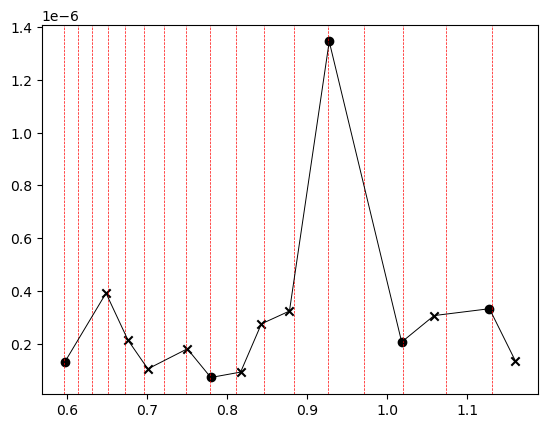

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df_filtered.sort_values(by='period')


plt.plot(df_filtered['period'], df_filtered['ampl'], color='black', linewidth=0.7)
for _, row in df_filtered.iterrows():
    if row['matches_PSP'] == 1:
        plt.scatter(row['period'], row['ampl'], color='black', marker='o')
    else:
        plt.scatter(row['period'], row['ampl'], color='black', marker='x')


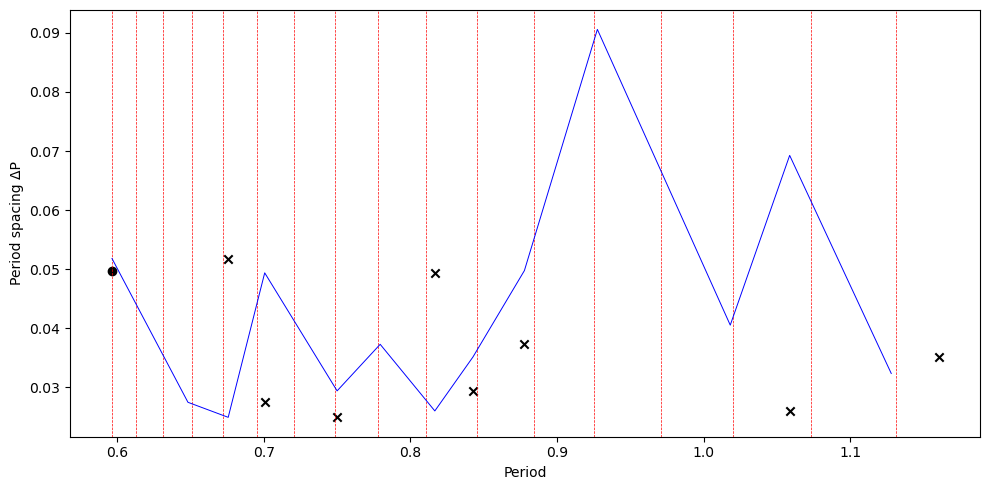

In [ ]:
# sorteer de periodes voor zekerheid
df_sorted = df_filtered.sort_values(by='period')

# extract arrays
P = df_sorted['period'].values
A = df_sorted['ampl'].values

# bereken period spacing ΔP
DeltaP = np.diff(P)      # lengte N-1
#P_mid  = (P[:-1] + P[1:]) / 2   # optioneel: plot bij het midden van elke interval

# plot ΔP vs period
plt.figure(figsize=(10,5))
for p in df_filtered['period_PSP']:
    plt.axvline(x=p, color='red', linestyle='--', linewidth=0.5)
plt.plot(P[:-1], DeltaP, color='blue', linewidth=0.7)
for i, row in df_filtered.iterrows():
    if row['matches_PSP'] == 1:
        plt.scatter(row['period'], DeltaP[i-1], color='black', marker='o')
    else:
        plt.scatter(row['period'], DeltaP[i-1], color='black', marker='x')
plt.xlabel("Period")
plt.ylabel("Period spacing ΔP")

plt.tight_layout()
plt.show()
